In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import read_db, read_db_old


warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

In [8]:
# name = "100_50050_train.h5"
# data = read_db_old(name, max_samples=10000)
name = "eval_large_m_42_10_1500.h5" 
data = read_db(name, max_samples=10000)
res = 16
field_idx = 4
nan_count = np.isnan(data["field"]).sum()
print(f"Number of NaN values in data['field']: {nan_count}")
print(f"Max size: {data['max_size']}")
print(f"Min size: {data['min_size']}")
# plots(data, loc=True, edge=True, number=True, idx=field_idx)

Number of NaN values in data['field']: 0
Max size: 0.4799884855747223
Min size: 0.12001306563615799


Mean: 22.452839 Std: 5.206154
2
17.07121


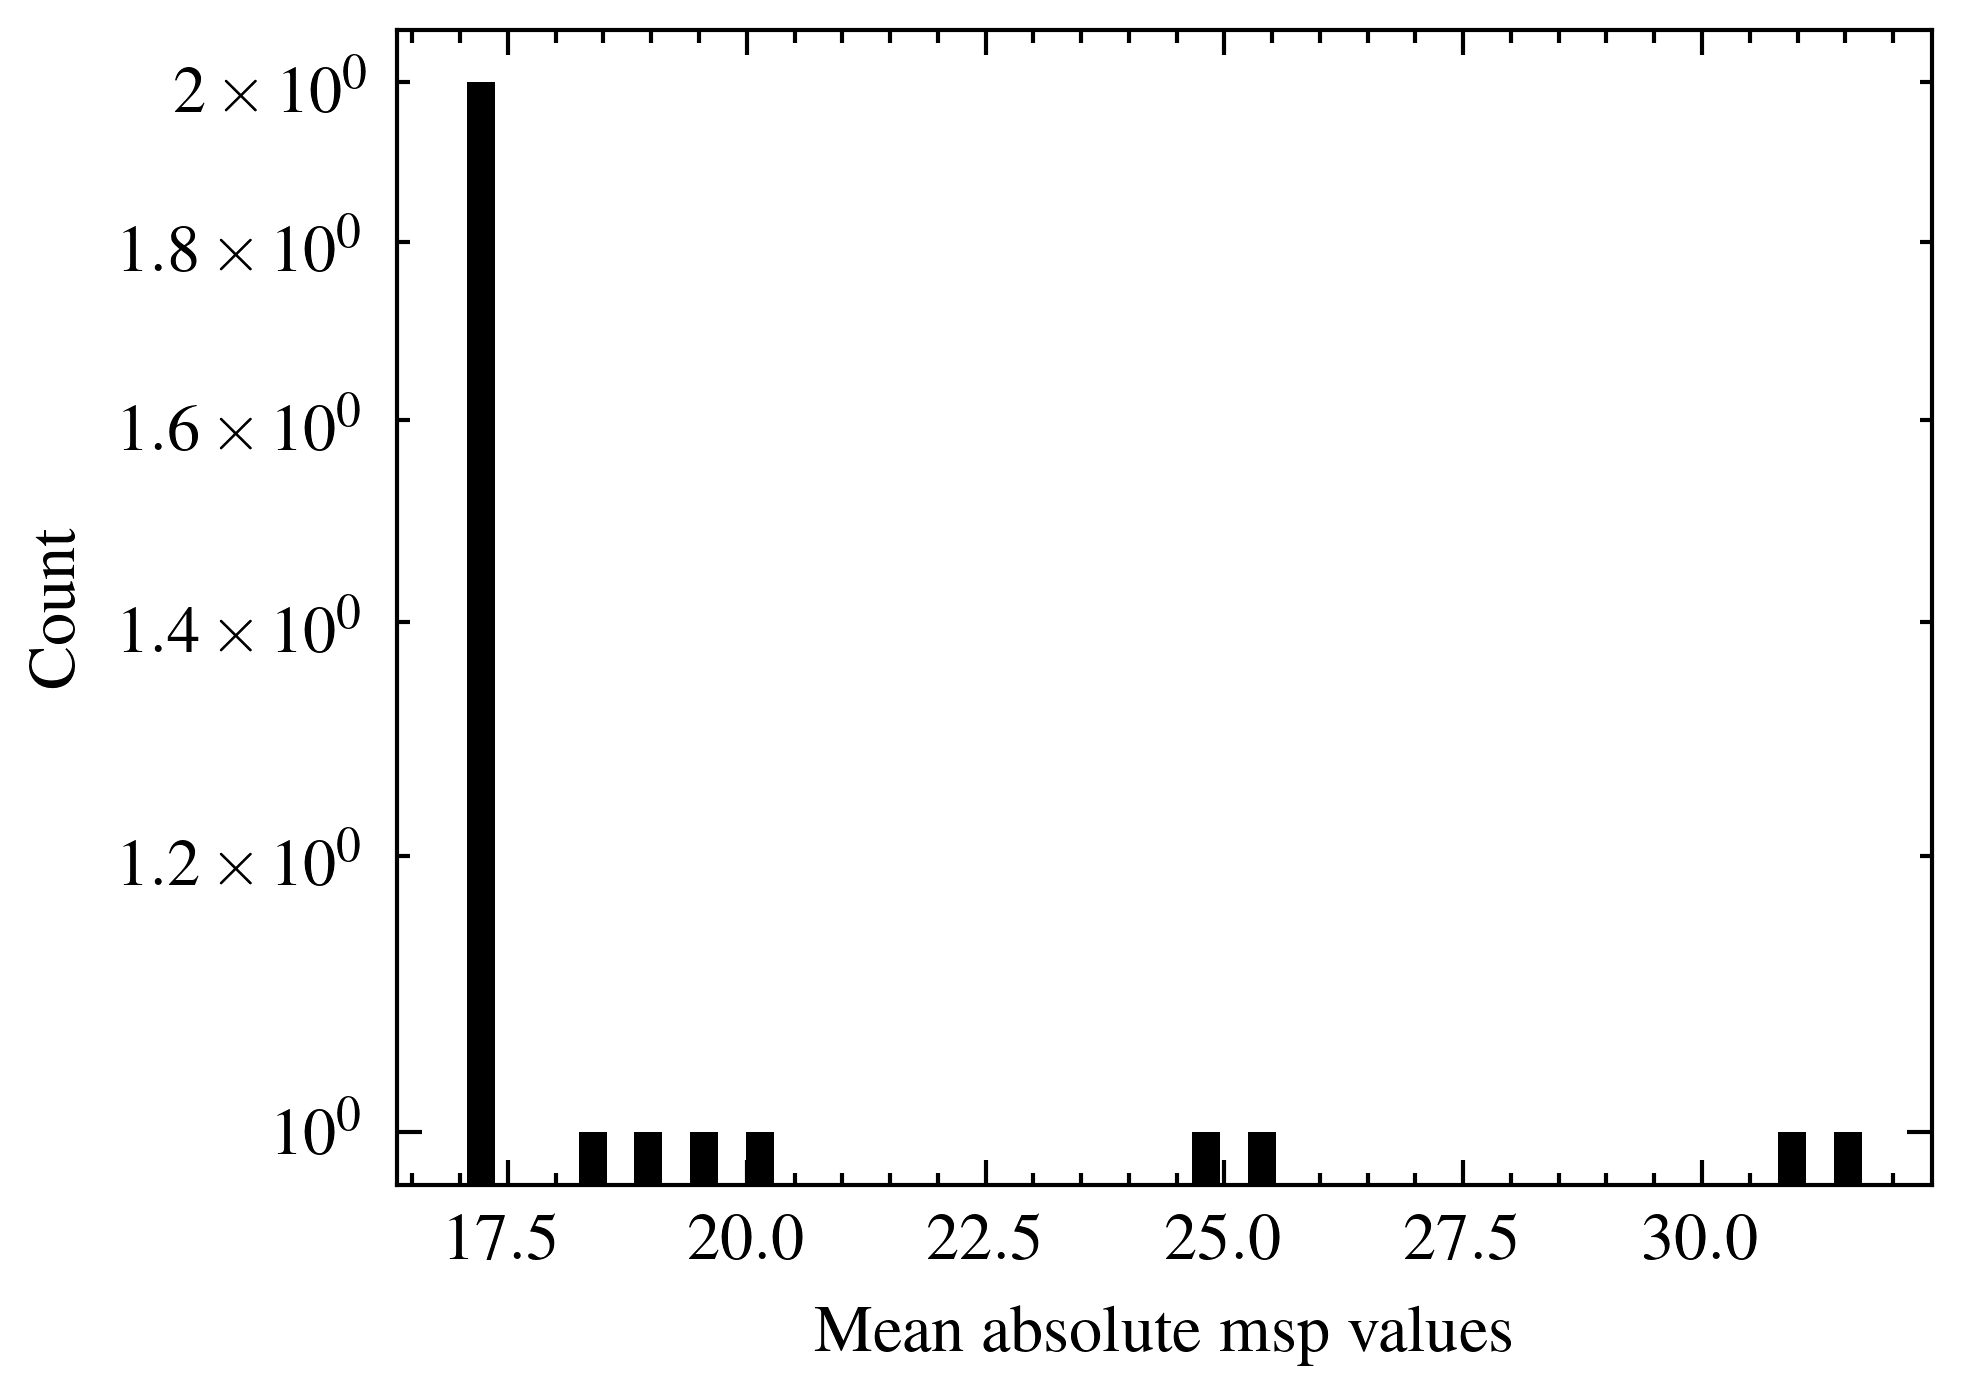

In [9]:
mean_abs = np.mean(np.abs(data["msp"]), axis=-1)
print("Mean:", np.mean(mean_abs), "Std:", np.std(mean_abs))
print(np.argmin(mean_abs))
print(mean_abs[np.argmin(mean_abs)])
plt.hist(mean_abs, bins=50)
plt.yscale("log")
plt.xlabel("Mean absolute msp values")
plt.ylabel("Count")
plt.show()

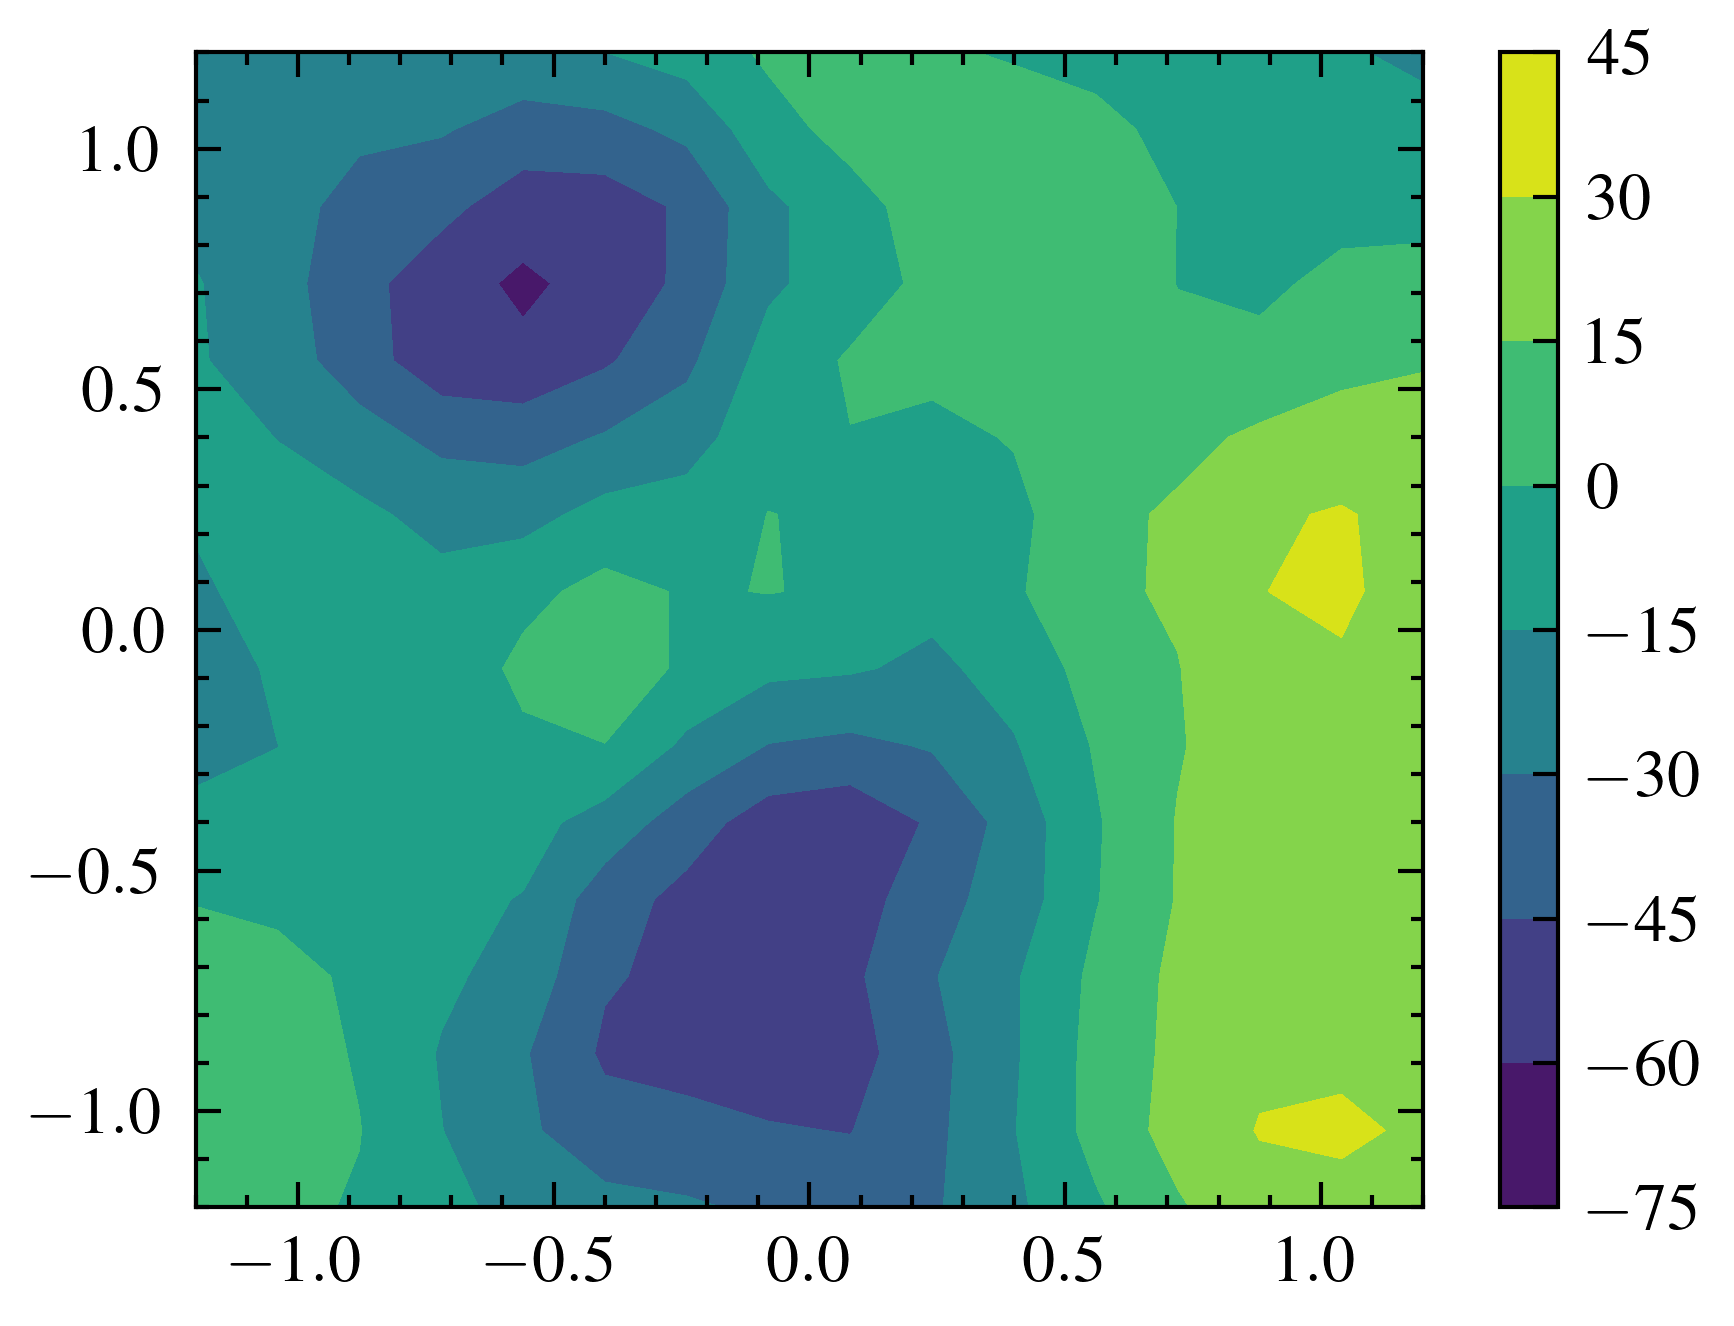

In [12]:
x_grid = np.array(data['grid'][:, 0].reshape((res, res)))
y_grid = np.array(data['grid'][:, 1].reshape((res, res)))
gt_msp = data["msp_grid"][field_idx].reshape((res, res))

plt.contourf(x_grid, y_grid, gt_msp)
plt.colorbar()

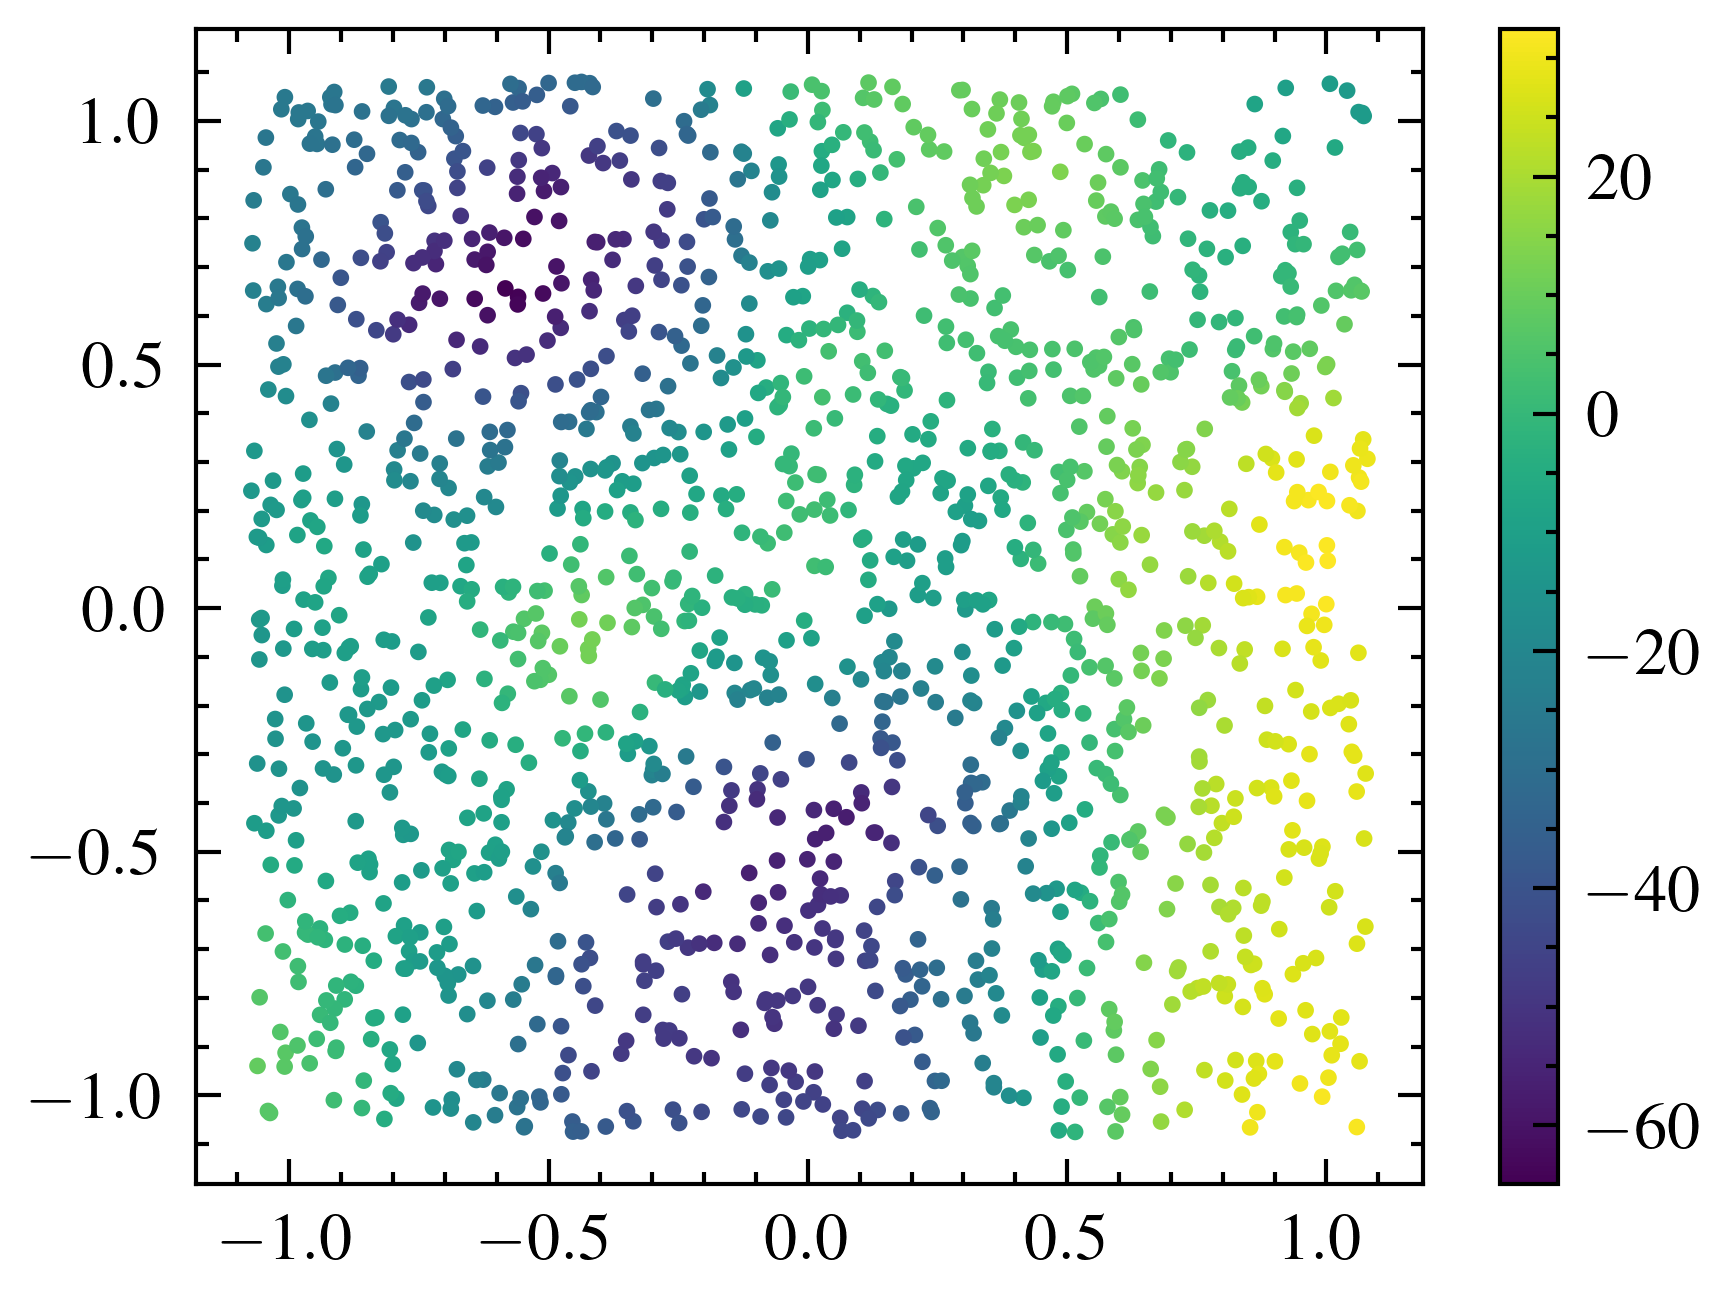

In [11]:
plt.scatter(data['r'][field_idx, :, 0], data['r'][field_idx, :, 1], c=data["msp"][field_idx], cmap='viridis', s=1)
plt.colorbar()